In [84]:
import pandas as pd
# from google.colab import files
# files.upload()

In [85]:
df = pd.read_csv('Salary Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [86]:
print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [87]:
df.dropna(axis = 0 , inplace = True)

In [88]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in df.select_dtypes(include = ['object']).columns:
  df[col] = encoder.fit_transform(df[col])

In [89]:
X = df.drop('Salary',axis = 1)
Y = df['Salary']

In [90]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
Y = scaler.fit_transform(Y.values.reshape(-1, 1))

In [91]:
import torch
X_train = torch.tensor(X, dtype=torch.float32)
Y_train = torch.tensor(Y, dtype=torch.float32)

In [92]:
import torch
import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_features, 6),
            nn.ReLU(),
            nn.Linear(6,1)
        )
    def forward(self, x):
        return self.net(x)



In [98]:
learning_rates = [0.1, 0.001, 0.02]
shape = X.shape[1]
num_epochs = 50
loss_history = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    model = MLP(shape)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    result = []
    for ep in range(num_epochs):
        model.train()
        y_preds = model(X_train)
        loss = criterion(y_preds, Y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        model.eval()
        result.append(loss.item())
        print(f"Epoch {ep+1}/{num_epochs} | MSE: {loss.item():.6f}")

    loss_history[lr] = result


Training with learning rate = 0.1
Epoch 1/50 | MSE: 0.905063
Epoch 2/50 | MSE: 0.732244
Epoch 3/50 | MSE: 0.593772
Epoch 4/50 | MSE: 0.472410
Epoch 5/50 | MSE: 0.368902
Epoch 6/50 | MSE: 0.292099
Epoch 7/50 | MSE: 0.235953
Epoch 8/50 | MSE: 0.197010
Epoch 9/50 | MSE: 0.171020
Epoch 10/50 | MSE: 0.154170
Epoch 11/50 | MSE: 0.143004
Epoch 12/50 | MSE: 0.135237
Epoch 13/50 | MSE: 0.129408
Epoch 14/50 | MSE: 0.124912
Epoch 15/50 | MSE: 0.121258
Epoch 16/50 | MSE: 0.118182
Epoch 17/50 | MSE: 0.115569
Epoch 18/50 | MSE: 0.113341
Epoch 19/50 | MSE: 0.111346
Epoch 20/50 | MSE: 0.109618
Epoch 21/50 | MSE: 0.108123
Epoch 22/50 | MSE: 0.106827
Epoch 23/50 | MSE: 0.105703
Epoch 24/50 | MSE: 0.104720
Epoch 25/50 | MSE: 0.103847
Epoch 26/50 | MSE: 0.103038
Epoch 27/50 | MSE: 0.102326
Epoch 28/50 | MSE: 0.101654
Epoch 29/50 | MSE: 0.101065
Epoch 30/50 | MSE: 0.100534
Epoch 31/50 | MSE: 0.100054
Epoch 32/50 | MSE: 0.099620
Epoch 33/50 | MSE: 0.099214
Epoch 34/50 | MSE: 0.098842
Epoch 35/50 | MSE: 0.0

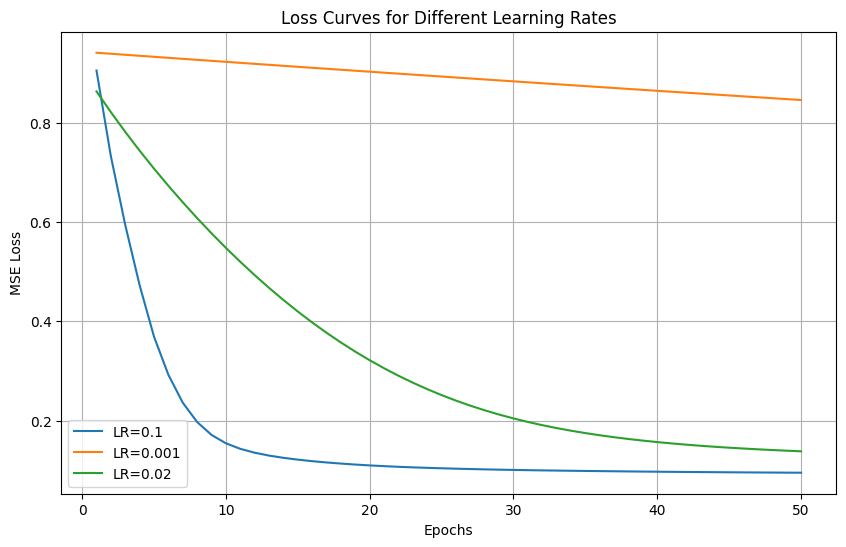

In [99]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for lr, losses in loss_history.items():
    plt.plot(range(1, num_epochs+1), losses, label=f"LR={lr}")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()